## Initialisation de l'environnement et chargement des données

In [1]:
import os
import math
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, RegexTokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.regression import RandomForestRegressor, LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

logging.basicConfig(level=logging.WARNING, format='%(message)s')

spark = SparkSession.builder \
    .appName("Airbnb_Pricing_Analysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

PATH_GOLD = "file:///home/onyxia/work/Data-factory/data/gold_ml"
TARGET = "price_log"

df = spark.read.parquet(PATH_GOLD)

In [2]:
print("Aperçu de la structure des données :")
df.printSchema()

print(f"Dimensions du jeu de données : {df.count()} lignes, {len(df.columns)} colonnes.")

print("\nÉchantillon brut des données (5 premières lignes) :")
df.show(5, truncate=False)

Aperçu de la structure des données :
root
 |-- id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- host_id: integer (nullable = true)
 |-- host_name: string (nullable = true)
 |-- neighbourhood: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- room_type: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- minimum_nights: integer (nullable = true)
 |-- number_of_reviews: integer (nullable = true)
 |-- last_review: string (nullable = true)
 |-- reviews_per_month: double (nullable = true)
 |-- calculated_host_listings_count: integer (nullable = true)
 |-- availability_365: integer (nullable = true)
 |-- price_log: double (nullable = true)
 |-- has_reviews: integer (nullable = true)
 |-- occupancy_rate: double (nullable = true)
 |-- zone_avg_price: double (nullable = true)
 |-- price_vs_zone_pct: double (nullable = true)
 |-- zone_type_avg_price: double (nullable = true)
 |-- neighbourhood_grou

Dimensions du jeu de données : 48870 lignes, 22 colonnes.

Échantillon brut des données (5 premières lignes) :


+-------+--------------------------------------------------+--------+----------------+-----------------+--------+---------+---------------+-----+--------------+-----------------+-----------+-----------------+------------------------------+----------------+---------+-----------+--------------+--------------+-----------------+-------------------+-------------------+
|id     |name                                              |host_id |host_name       |neighbourhood    |latitude|longitude|room_type      |price|minimum_nights|number_of_reviews|last_review|reviews_per_month|calculated_host_listings_count|availability_365|price_log|has_reviews|occupancy_rate|zone_avg_price|price_vs_zone_pct|zone_type_avg_price|neighbourhood_group|
+-------+--------------------------------------------------+--------+----------------+-----------------+--------+---------+---------------+-----+--------------+-----------------+-----------+-----------------+------------------------------+----------------+---------+

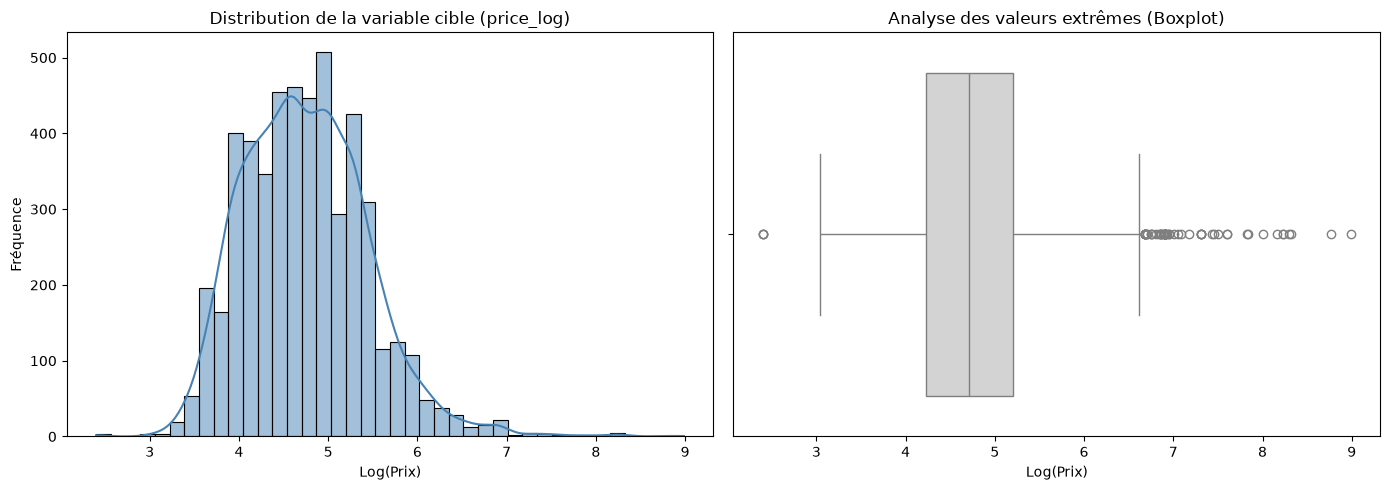

In [3]:
df_sample = df.sample(fraction=0.1, seed=42).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_sample[TARGET], kde=True, color='steelblue', bins=40, ax=axes[0])
axes[0].set_title("Distribution de la variable cible (price_log)")
axes[0].set_xlabel("Log(Prix)")
axes[0].set_ylabel("Fréquence")

sns.boxplot(x=df_sample[TARGET], color='lightgray', ax=axes[1])
axes[1].set_title("Analyse des valeurs extrêmes (Boxplot)")
axes[1].set_xlabel("Log(Prix)")

plt.tight_layout()
plt.show()

colonnes_numeriques = [t[0] for t in df.dtypes if t[1] in ['int', 'double', 'float', 'bigint']]
df_num_sample = df_sample[colonnes_numeriques]

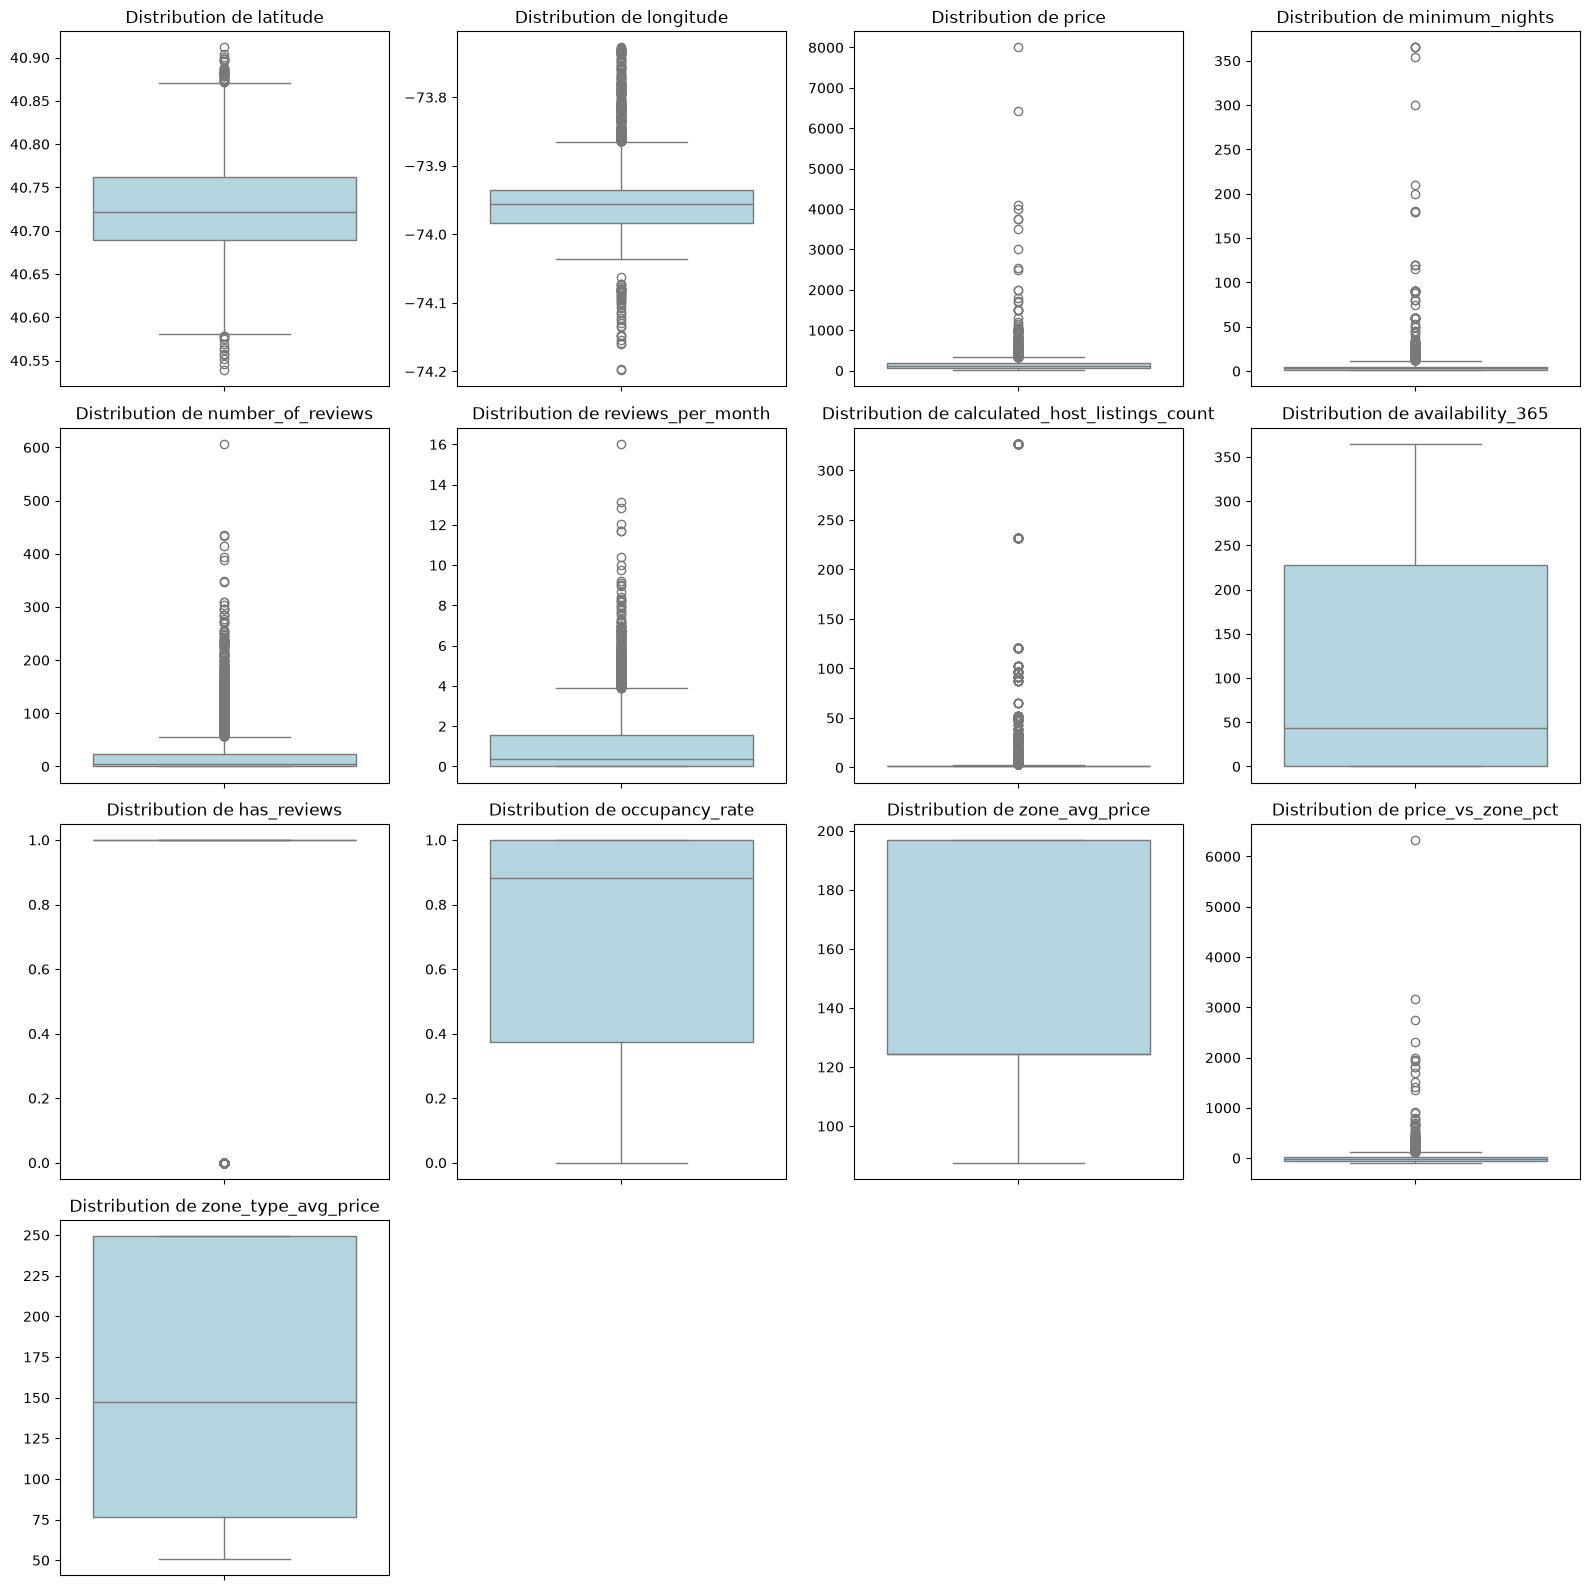

In [4]:
colonnes_pertinentes = [c for c in colonnes_numeriques if c not in ['id', 'host_id', TARGET]]

n_cols = len(colonnes_pertinentes)
n_rows = math.ceil(n_cols / 4)

plt.figure(figsize=(16, 4 * n_rows))
for i, col in enumerate(colonnes_pertinentes, 1):
    plt.subplot(n_rows, 4, i)
    sns.boxplot(y=df_num_sample[col], color='lightblue')
    plt.title(f"Distribution de {col}")
    plt.ylabel("")
plt.tight_layout()
plt.show()


In [5]:
#Observations : Des variables comme 'minimum_nights' ou 'number_of_reviews' comportent des valeurs extrêmes très étalées qui reflètent la réalité du marché.

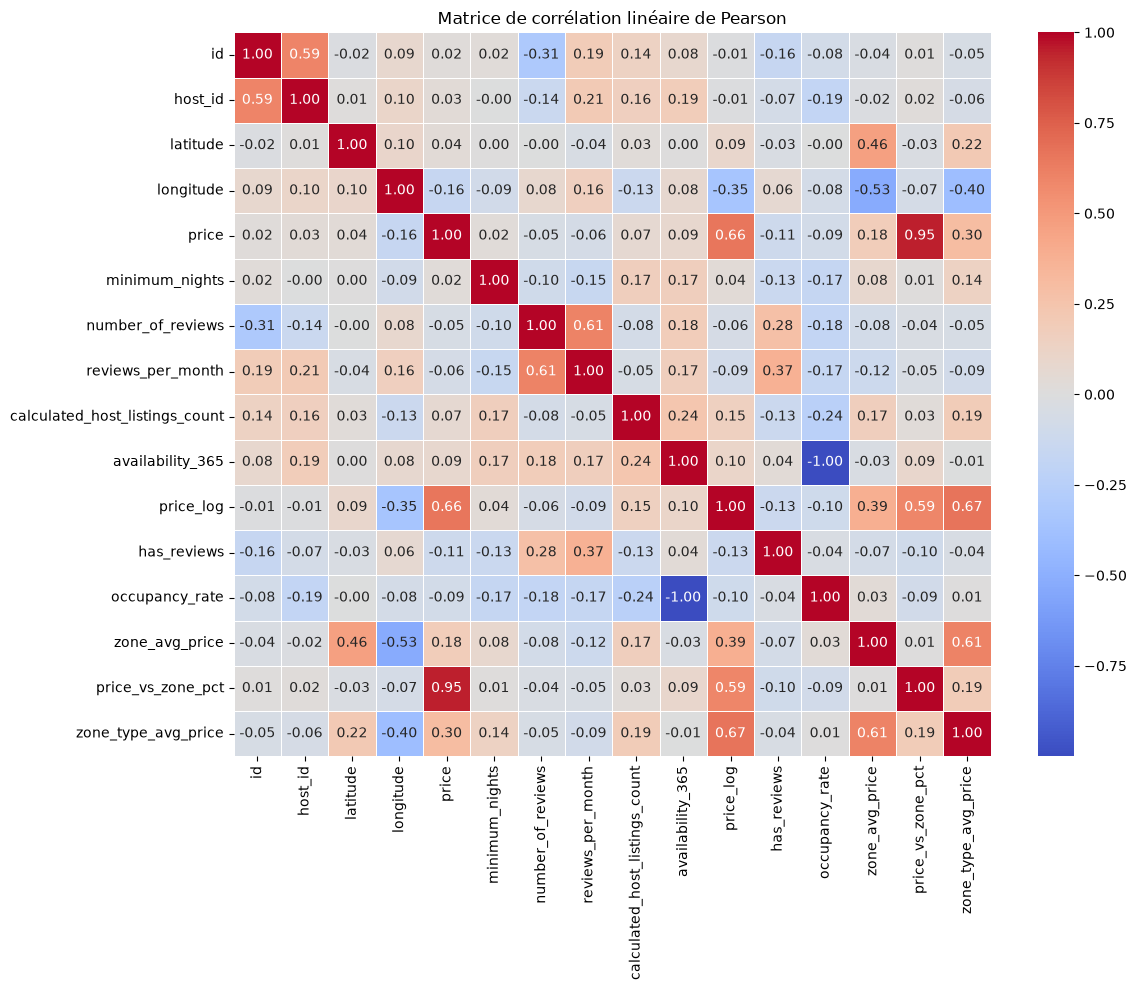

In [6]:
#Matrice de corrélation
plt.figure(figsize=(12, 10))
corr_matrix = df_num_sample.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation linéaire de Pearson")
plt.tight_layout()
plt.show()

In [7]:
# Analyse de la matrice de corrélation 
# On observe une corrélation très élevée (> 0.90) entre les variables 'price_vs_zone_pct', 'zone_type_avg_price' et la cible 'price_log'.
# Ces variables dérivent directement du prix (fuite de données) et seront exclues de la modélisation.

In [8]:
df.select("name").sample(fraction=0.01, seed=42).show(15, truncate=False)

+--------------------------------------------------------+
|name                                                    |
+--------------------------------------------------------+
|UWS 2 BR 2 Ba. Gorgeous Apt!                            |
|Stunning 2 bed 2bath Wall St. Luxury Apt                |
|Midtown Manhattan steps from 5thAve                     |
|1BR in downtown Manhattan                               |
|Beautiful one bedroom in Soho                           |
|*LUSH SPACIOUS WEST VILLAGE LOFT*                       |
|Large, True 1BR - Heart of Nolita/Soho/LittleItaly      |
|Doorman Elevator Prime Location UN! 5242                |
|Bright, spacious 1br in Harlem | Near 4/5/6 train       |
|CLEAN Downtown Studio Crash Pad!                        |
|Enjoy this vast, chic apt, 15-to-Midtown w/Kingbed      |
|light filled chic west village apt                      |
|Sonder | Stock Exchange | Tasteful 3BR + Kitchen        |
|Sunny Spacious Studio, Subway Right Downstairs!        

In [10]:
cols_to_exclude = [TARGET, 'price', 'price_vs_zone_pct', 'zone_type_avg_price', 'id', 'host_id', 'name']

base_numeric_features = [
    t[0] for t in df.dtypes 
    if t[1] in ['int', 'double', 'float', 'bigint'] and t[0] not in cols_to_exclude
]
base_categorical_features = ['room_type', 'neighbourhood']

base_stages = []

for categorical_col in base_categorical_features:
    indexer = StringIndexer(inputCol=categorical_col, outputCol=f"{categorical_col}_idx", handleInvalid="keep")
    encoder = OneHotEncoder(inputCol=f"{categorical_col}_idx", outputCol=f"{categorical_col}_ohe")
    base_stages += [indexer, encoder]

base_assembler_inputs = base_numeric_features + [f"{c}_ohe" for c in base_categorical_features]
base_assembler = VectorAssembler(inputCols=base_assembler_inputs, outputCol="features_baseline", handleInvalid="skip")
base_stages += [base_assembler]

pipeline_baseline = Pipeline(stages=base_stages)
df_baseline = pipeline_baseline.fit(df).transform(df)

train_baseline, test_baseline = df_baseline.randomSplit([0.8, 0.2], seed=42)

models_baseline = {
    "Linear Regression (Base)": LinearRegression(featuresCol="features_baseline", labelCol=TARGET, regParam=0.01, elasticNetParam=0.3),
    "Random Forest (Base)": RandomForestRegressor(featuresCol="features_baseline", labelCol=TARGET, numTrees=50, maxDepth=5, seed=42),
    "Gradient Boosting (Base)": GBTRegressor(featuresCol="features_baseline", labelCol=TARGET, maxIter=30, maxDepth=4, stepSize=0.1, seed=42)
}

evaluator_r2 = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="rmse")

print("\nPerformances Itération 1 : Modèles de base")
print("-" * 65)
print(f"{'Modèle':<32} | {'R²':<10} | {'RMSE':<10}")
print("-" * 65)

for name, estimator in models_baseline.items():
    model = estimator.fit(train_baseline)
    preds = model.transform(test_baseline)
    r2 = evaluator_r2.evaluate(preds)
    rmse = evaluator_rmse.evaluate(preds)
    print(f"{name:<32} | {r2:.4f}     | {rmse:.4f}")


Performances Itération 1 : Modèles de base
-----------------------------------------------------------------
Modèle                           | R²         | RMSE      
-----------------------------------------------------------------


Linear Regression (Base)         | 0.5482     | 0.4622


Random Forest (Base)             | 0.5418     | 0.4655


Gradient Boosting (Base)         | 0.5823     | 0.4445


In [12]:
#  (Feature Engineering)
# Objectif : Améliorer les performances en extrayant des informations latentes 
# Extractiondu texte et en créant des repères géospatiaux.

df_adv = df.fillna({"name": "unknown"})
df_adv = df_adv.fillna(0.0)

# Extraction textuelle via expressions régulières
df_adv = df_adv.withColumn(
    "is_studio", F.when(F.lower(F.col("name")).rlike("studio"), 1.0).otherwise(0.0)
).withColumn(
    "is_loft", F.when(F.lower(F.col("name")).rlike("loft"), 1.0).otherwise(0.0)
)

df_adv = df_adv.withColumn(
    "bedrooms_extracted", 
    F.regexp_extract(F.lower(F.col("name")), r"(\d+)\s*(?:br|bdrm|bedroom|bed|bdr)", 1)
)
df_adv = df_adv.withColumn(
    "bedrooms_extracted", 
    F.when(F.col("bedrooms_extracted") == "", "0").otherwise(F.col("bedrooms_extracted")).cast("double")
).withColumn(
    "bedrooms_extracted",
    F.when(F.col("is_studio") == 1.0, 0.0).otherwise(F.col("bedrooms_extracted"))
)

premium_keywords = ["luxury", "spacious", "view", "private", "renovated", "huge"]
for kw in premium_keywords:
    df_adv = df_adv.withColumn(f"has_{kw}", F.when(F.lower(F.col("name")).rlike(kw), 1.0).otherwise(0.0))

# Extraction géospatiale
LAT_CENTER, LON_CENTER = 40.7580, -73.9855
LAT_JFK, LON_JFK = 40.6413, -73.7781

df_adv = df_adv.withColumn(
    "distance_center", 
    F.sqrt(F.pow(F.col("latitude") - LAT_CENTER, 2) + F.pow(F.col("longitude") - LON_CENTER, 2))
).withColumn(
    "distance_jfk",
    F.sqrt(F.pow(F.col("latitude") - LAT_JFK, 2) + F.pow(F.col("longitude") - LON_JFK, 2))
).withColumn(
    "name_length",
    F.length(F.col("name"))
)

print("\nVisualisation des nouvelles caractéristiques (Feature Engineering) :")
colonnes_creees = ["name", "is_studio", "bedrooms_extracted", "has_luxury", "distance_center", "name_length"]
df_adv.select(colonnes_creees).sample(fraction=0.01, seed=42).show(10, truncate=False)



Visualisation des nouvelles caractéristiques (Feature Engineering) :


+--------------------------------------------------+---------+------------------+----------+--------------------+-----------+
|name                                              |is_studio|bedrooms_extracted|has_luxury|distance_center     |name_length|
+--------------------------------------------------+---------+------------------+----------+--------------------+-----------+
|UWS 2 BR 2 Ba. Gorgeous Apt!                      |0.0      |2.0               |0.0       |0.025210801256603788|28         |
|Stunning 2 bed 2bath Wall St. Luxury Apt          |0.0      |2.0               |1.0       |0.05731121443487601 |40         |
|Midtown Manhattan steps from 5thAve               |0.0      |0.0               |0.0       |0.01031187664782091 |35         |
|1BR in downtown Manhattan                         |0.0      |1.0               |0.0       |0.030787453613449492|25         |
|Beautiful one bedroom in Soho                     |0.0      |0.0               |0.0       |0.035238508765267136|29   

In [13]:
# Itération 2 - Modélisation 
adv_numeric_features = [
    t[0] for t in df_adv.dtypes 
    if t[1] in ['int', 'double', 'float', 'bigint'] and t[0] not in cols_to_exclude
]

adv_stages = []

for categorical_col in base_categorical_features:
    indexer = StringIndexer(inputCol=categorical_col, outputCol=f"{categorical_col}_idx_adv", handleInvalid="keep")
    encoder = OneHotEncoder(inputCol=f"{categorical_col}_idx_adv", outputCol=f"{categorical_col}_ohe_adv")
    adv_stages += [indexer, encoder]

tokenizer = RegexTokenizer(inputCol="name", outputCol="words", pattern="\\W")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
hashingTF = HashingTF(inputCol="filtered_words", outputCol="rawFeatures", numFeatures=100)
idf = IDF(inputCol="rawFeatures", outputCol="tf_idf_features")
adv_stages += [tokenizer, remover, hashingTF, idf]

adv_assembler_inputs = adv_numeric_features + [f"{c}_ohe_adv" for c in base_categorical_features] + ["tf_idf_features"]
adv_assembler = VectorAssembler(inputCols=adv_assembler_inputs, outputCol="features_advanced", handleInvalid="skip")
adv_stages += [adv_assembler]

pipeline_advanced = Pipeline(stages=adv_stages)
df_model_advanced = pipeline_advanced.fit(df_adv).transform(df_adv)

train_adv, test_adv = df_model_advanced.randomSplit([0.8, 0.2], seed=42)

models_advanced = {
    "Linear Regression (Avancé)": LinearRegression(featuresCol="features_advanced", labelCol=TARGET, regParam=0.01, elasticNetParam=0.3),
    "Random Forest (Avancé)": RandomForestRegressor(featuresCol="features_advanced", labelCol=TARGET, numTrees=120, maxDepth=8, seed=42),
    "Gradient Boosting (Avancé)": GBTRegressor(featuresCol="features_advanced", labelCol=TARGET, maxIter=175, maxDepth=6, stepSize=0.05, seed=42)
}

print("\nPerformances Itération 2 : Modèles avec caractéristiques avancées")
print("-" * 65)
print(f"{'Modèle':<32} | {'R²':<10} | {'RMSE':<10}")
print("-" * 65)

trained_models_adv = {}
for name, estimator in models_advanced.items():
    model = estimator.fit(train_adv)
    trained_models_adv[name] = model
    preds = model.transform(test_adv)
    r2 = evaluator_r2.evaluate(preds)
    rmse = evaluator_rmse.evaluate(preds)
    print(f"{name:<32} | {r2:.4f}     | {rmse:.4f}")

best_model = trained_models_adv["Gradient Boosting (Avancé)"] 
best_preds = best_model.transform(test_adv)


Performances Itération 2 : Modèles avec caractéristiques avancées
-----------------------------------------------------------------
Modèle                           | R²         | RMSE      
-----------------------------------------------------------------


Linear Regression (Avancé)       | 0.5873     | 0.4418


Random Forest (Avancé)           | 0.6115     | 0.4286


Gradient Boosting (Avancé)       | 0.6377     | 0.4139


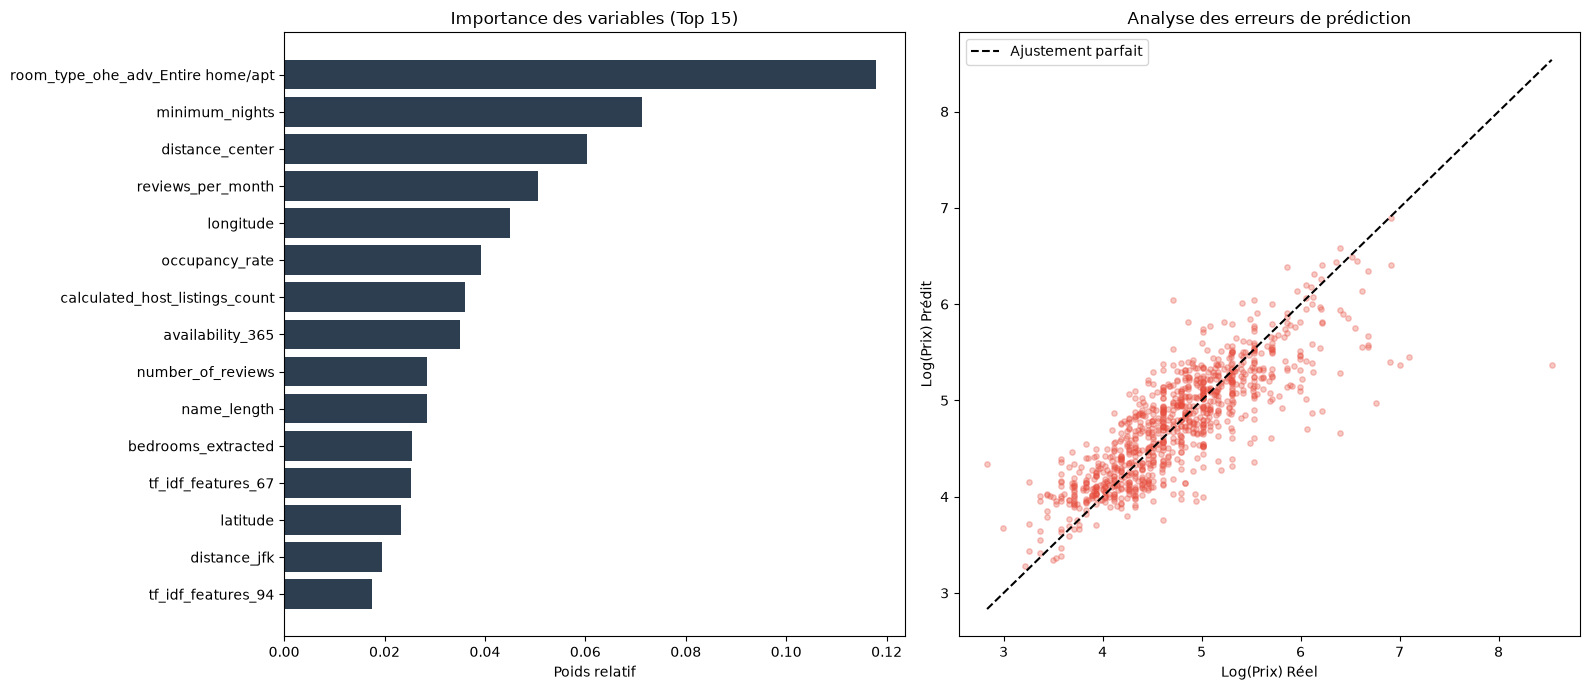

In [14]:
# Interprétabilité du modèle final
importances = best_model.featureImportances.toArray()

try:
    attrs = best_preds.schema["features_advanced"].metadata["ml_attr"]["attrs"]
    feature_names = []
    for attr_type in ["numeric", "binary", "nominal"]:
        if attr_type in attrs:
            feature_names.extend([{"idx": attr["idx"], "name": attr["name"]} for attr in attrs[attr_type]])
    feature_names = [x["name"] for x in sorted(feature_names, key=lambda x: x["idx"])]
except Exception:
    feature_names = [f"Feature_{i}" for i in range(len(importances))]

top_n = 15
indices = np.argsort(importances)[-top_n:]
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(top_features, top_importances, color='#2c3e50')
axes[0].set_xlabel("Poids relatif")
axes[0].set_title(f"Importance des variables (Top {top_n})")

df_preds_sample = best_preds.select(TARGET, "prediction").sample(fraction=0.1, seed=42).toPandas()
axes[1].scatter(df_preds_sample[TARGET], df_preds_sample["prediction"], alpha=0.3, color='#e74c3c', s=15)

min_val = min(df_preds_sample[TARGET].min(), df_preds_sample["prediction"].min())
max_val = max(df_preds_sample[TARGET].max(), df_preds_sample["prediction"].max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=1.5, label="Ajustement parfait")

axes[1].set_xlabel("Log(Prix) Réel")
axes[1].set_ylabel("Log(Prix) Prédit")
axes[1].set_title("Analyse des erreurs de prédiction")
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
#  Exportation du modèle
export_dir = "/home/onyxia/work/Data-factory/models"
os.makedirs(export_dir, exist_ok=True)
export_path = f"file://{export_dir}/airbnb_gbt_model"

try:
    best_model.write().overwrite().save(export_path)
    print(f"\nExportation réussie. Modèle sauvegardé dans : {export_path}")
except Exception as e:
    print(f"\nErreur d'exportation : {e}")


Exportation réussie. Modèle sauvegardé dans : file:///home/onyxia/work/Data-factory/models/airbnb_gbt_model
